# Import the Relevant Libraries

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


pd.set_option('display.max_columns', None) #Displays all columns

# Load the data set

In [2]:
financial_df = pd.read_excel("../data_raw/finaccess2024_datasprint.xlsx")

In [3]:


pd.set_option("display.max_columns", None)
financial_df.head(10)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability
5,Kilifi,Rural,Female,Above 55,3,"""Secondary completed """,Married/Living with partner,4000,Non-usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,No,Yes,No,No,No,Worsened,All correct,2,Affordability,Without Disability
6,Meru,Rural,Female,36-45,6,"""Some primary """,Single/Never Married,1000,Non-usage,Usage,Non-usage,Usage,Yes,Usage,Yes,0,Yes,No,Yes,No,No,No,No,Stayed the same,All correct,4,Affordability,Without Disability
7,Kilifi,Rural,Male,36-45,7,"""Some primary """,Married/Living with partner,8500,Non-usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,0,Yes,Yes,No,Yes,Yes,No,No,Worsened,One correct,2,Affordability,Without Disability
8,Kisumu,Urban,Female,26-35,4,"""Primary completed""",Married/Living with partner,1500,Usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,No,Yes,No,Worsened,Two correct,3,Affordability,Without Disability
9,Baringo,Urban,Male,26-35,1,"""Secondary completed """,Married/Living with partner,6500,Usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,0,Yes,Yes,No,No,No,Yes,No,Improved,All correct,12,NaN,Without Disability


# Checking the structure of the dataset

In [4]:
def basic_checks(df):
    print("Shape:\n " , df.shape)
    print (64 * "#")
    print("Duplicates:\n",financial_df.duplicated().sum)
    print (64 * "#")
    print("Columns:\n " , financial_df.columns)
    print (64 * "#")
    print(financial_df.dtypes)
    print (64 * "#")
    print("Checking missing values: \n", financial_df.isnull().sum)
    print (64 * "#")
    print("Checking datatype:\n", df.info())
    print (64 * "#")
    print("Numerical summary statistics:\n ",financial_df.describe().T)
    print (64 * "#")
    print(" Categorical summary statistics:\n",financial_df.describe(include = ["str","object"]).T)
    

In [5]:
basic_checks(financial_df)

Shape:
  (20871, 28)
################################################################
Duplicates:
 <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
20866    False
20867    False
20868    False
20869    False
20870    False
Length: 20871, dtype: bool>
################################################################
Columns:
  Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')
################################################################
county  

# Checking the categories in categorical columns

basic

In [6]:
categorical_cols = financial_df.select_dtypes(include = ['str','object']).columns.to_list()
print(categorical_cols)

['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status', 'fl_score', 'barriers_bank', 'has_disability']


In [7]:
for col in categorical_cols:
    print(64 * '-',col, 64 * '-')
    print(financial_df[col].unique())

---------------------------------------------------------------- county ----------------------------------------------------------------
<StringArray>
[        'Garissa',           'Busia',          'Kiambu',        'Murang'a',
          'Kilifi',            'Meru',          'Kisumu',         'Baringo',
          'Isiolo',            'Embu',         'Mombasa', 'Elgeyo-Marakwet',
         'Homabay',          'Migori',           'Siaya',      'West Pokot',
           'Nyeri',           'Bomet',         'Makueni',     'Uasin Gishu',
         'Bungoma',          'Nakuru',        'Kakamega',           'Kwale',
           'Kitui',         'Mandera',    'Nairobi City',        'Machakos',
   'Tharaka-Nithi',       'Nyandarua',        'Marsabit',       'Kirinyaga',
         'Kericho',           'Kisii',    'Taita-Taveta',          'Vihiga',
     'Trans Nzoia',           'Narok',         'Kajiado',        'Laikipia',
           'Nandi',            'Lamu',         'Turkana',         'Samburu',
  

# checking outliers

In [8]:
numerical_cols = financial_df.select_dtypes(include = ['float','int']).columns.to_list()
print(numerical_cols)

['household_size', 'monthly_income', 'prodsum1']


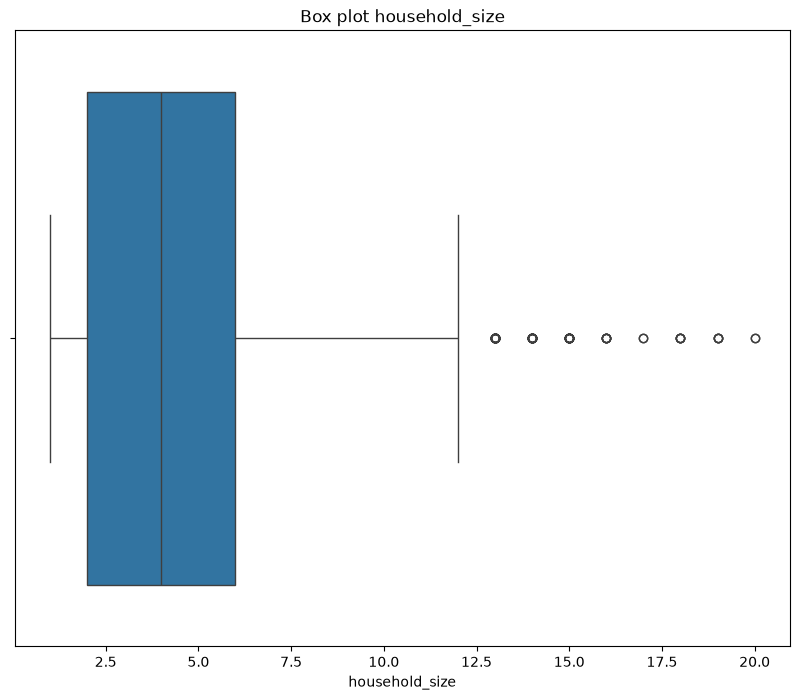

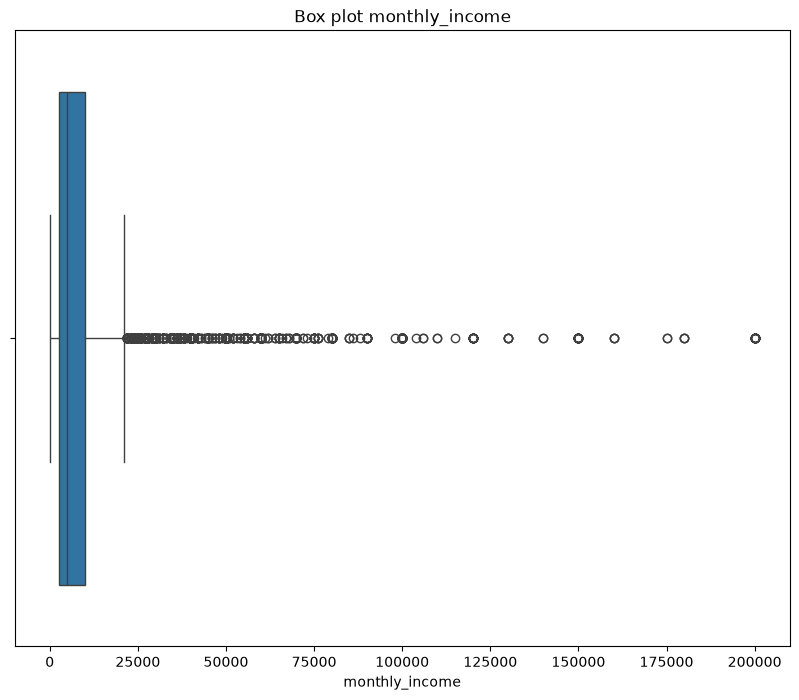

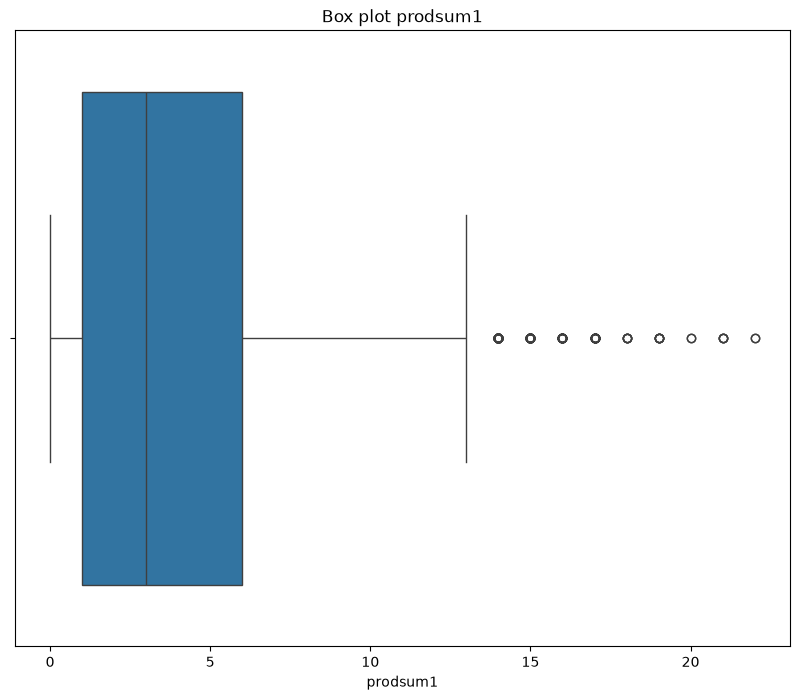

In [9]:
for cols in numerical_cols:
    plt.figure (figsize  = [10,8])
    sns.boxplot(data=financial_df, x=cols)
    plt.title(f'Box plot {cols}')
    plt.show()

** Boxplot**

![boxplot]("https://www.simplypsychology.org/wp-content/uploads/image-3.jpeg")

# Data Cleaning

In [10]:
# Converting columns names to lowercase

financial_df.columns = financial_df.columns.astype(str).str.lower()
financial_df.columns

Index(['county', 'location_type', 'sex', 'age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'savings_formal',
       'savings_informal', 'loan_formal', 'loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

# cleaning level of education column

In [11]:
financial_df['education_level'].unique()

array(['Completed technical training after secondary school', '"None "',
       '"Primary completed"', '"Some secondary"',
       'Some technical training after secondary school',
       '"Secondary completed "', '"Some primary "',
       '"University completed "', '"Other (Specify) "', 'Some university',
       95, '"Refused to Answer (DO NOT READ OUT)"',
       '"Don\'t know (DO NOT READ OUT)"'], dtype=object)

In [12]:
mapping = {
    'Completed technical training after secondary school':'Technical Training completed',
    '"None "': 'None',
    '"Primary completed"': 'Primary completed',
    '"Some secondary"': 'Secondary incomplete' ,
    'Some technical training after secondary school': 'Technical training incomplete',
    '"Secondary completed "': 'Secondary completed',
    '"Some primary "': 'Primary incomplete',
    '"University completed "': 'University completed',
    'Some university': 'University incomplete'}


financial_df['education_level'] = financial_df['education_level'].replace(mapping)

financial_df['education_level'].unique()

array(['Technical Training completed', 'None', 'Primary completed',
       'Secondary incomplete', 'Technical training incomplete',
       'Secondary completed', 'Primary incomplete',
       'University completed', '"Other (Specify) "',
       'University incomplete', 95,
       '"Refused to Answer (DO NOT READ OUT)"',
       '"Don\'t know (DO NOT READ OUT)"'], dtype=object)

# checking for the proportion of each category in education column

In [13]:
(financial_df['education_level'].value_counts()/len(financial_df))*100

education_level
Secondary completed                      19.706770
Primary completed                        18.940156
Primary incomplete                       17.876479
None                                     14.747736
Secondary incomplete                     13.085142
Technical Training completed              6.808490
University completed                      4.733841
Technical training incomplete             2.400460
University incomplete                     1.657803
"Refused to Answer (DO NOT READ OUT)"     0.014374
"Other (Specify) "                        0.009583
95                                        0.009583
"Don't know (DO NOT READ OUT)"            0.009583
Name: count, dtype: float64

# Dropping unnecessary categories in educational level columns

In [14]:
cat_to_drop = ['"Refused to Answer (DO NOT READ OUT)"','"Other (Specify) "' ,95, '"Don\'t know (DO NOT READ OUT)"']

financial_df = financial_df[~financial_df['education_level'].isin(cat_to_drop)].copy()

In [15]:
(financial_df['education_level'].value_counts()/len(financial_df))*100

education_level
Secondary completed              19.715272
Primary completed                18.948327
Primary incomplete               17.884191
None                             14.754098
Secondary incomplete             13.090787
Technical Training completed      6.811427
University completed              4.735883
Technical training incomplete     2.401496
University incomplete             1.658518
Name: count, dtype: float64

# Cleaning categories for marital status

In [16]:
financial_df['marital_status'].unique()

<StringArray>
[       'Married/Living with partner',                 'Divorced/separated',
               'Single/Never Married',                            'Widowed',
     'Don't know   (DO NOT READ OUT)', 'Refused to Answer(DO NOT READ OUT)']
Length: 6, dtype: str

In [17]:
mapping = {
    'Married/Living with partner': 'Married',
     'Divorced/separated': 'Divorced',
     'Single/Never Married':'Single',
      'Widowed': 'Windowed',
}

financial_df['marital_status']= financial_df['marital_status'].replace(mapping)

financial_df['marital_status'].unique()

<StringArray>
[                           'Married',                           'Divorced',
                             'Single',                           'Windowed',
     'Don't know   (DO NOT READ OUT)', 'Refused to Answer(DO NOT READ OUT)']
Length: 6, dtype: str

In [18]:
(financial_df['marital_status'].value_counts()/len(financial_df))*100

marital_status
Married                               54.783817
Single                                27.633976
Windowed                              10.703672
Divorced                               6.835394
Don't know   (DO NOT READ OUT)         0.023967
Refused to Answer(DO NOT READ OUT)     0.019174
Name: count, dtype: float64

In [19]:
cat_to_drop = ['Don\'t know   (DO NOT READ OUT)','Refused to Answer(DO NOT READ OUT)']

financial_df = financial_df[~financial_df['marital_status'].isin(cat_to_drop)].copy()

In [20]:
(financial_df['marital_status'].value_counts()/len(financial_df))*100

marital_status
Married     54.807462
Single      27.645902
Windowed    10.708291
Divorced     6.838345
Name: count, dtype: float64

# cleaning barriers bank categories entries

In [21]:
mapping = {0 : 'None'}

financial_df['barriers_mobile_money']  = financial_df['barriers_mobile_money'].replace(mapping)

financial_df.barriers_mobile_money.unique()

array(['None', 'Eligibility', 'Phone ownership', 'Line blocked', 'Other',
       'Affordability', 'Relevance/Suitability', 'Awareness',
       'Service quality', 'Trust'], dtype=object)

# Dropping duplicates

In [22]:
fiancial_df= financial_df.drop_duplicates()

financial_df.duplicated().sum()

np.int64(5)

# Missing Values

In [23]:
(financial_df.isna().sum()/len(financial_df))*100

county                    0.000000
location_type             0.000000
sex                       0.000000
age                       0.000000
household_size            0.000000
education_level           0.000000
marital_status            0.000000
monthly_income            0.000000
savings_formal            0.000000
savings_informal          0.000000
loan_formal               0.000000
loan_informal             0.000000
defaulted                 0.000000
formal_service_use        0.000000
mobile_money_access       0.000000
barriers_mobile_money     0.000000
mobile_ownership_1        0.000000
experienced_shock         0.000000
nfhi_11                   0.000000
nfhi_12                   0.000000
nfhi_13                   0.000000
accessto_13k_1month       0.000000
not_difficult             0.000000
financial_status          0.000000
fl_score                  0.000000
prodsum1                  0.000000
barriers_bank            27.478061
has_disability            0.000000
dtype: float64

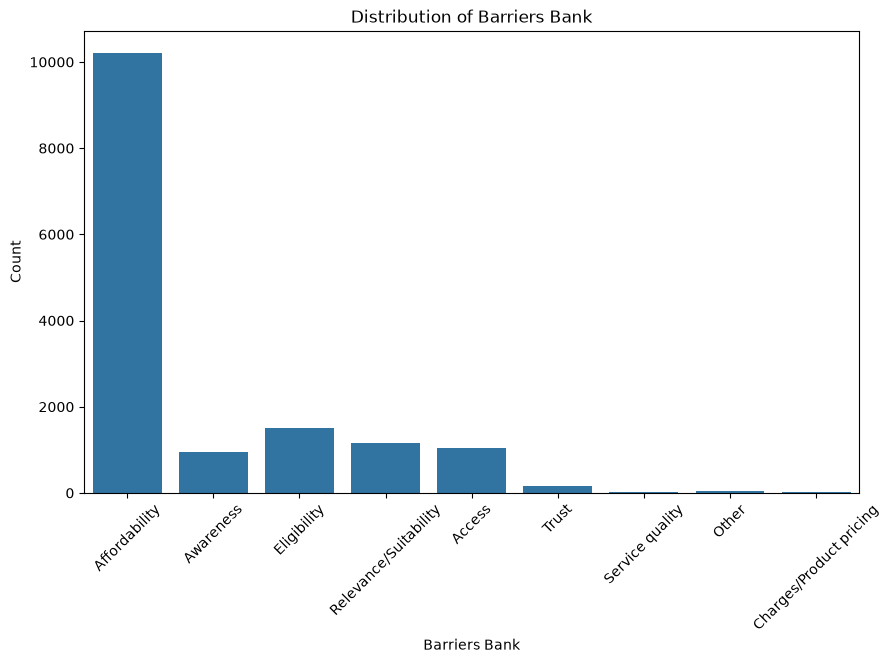

In [24]:
plt.figure(figsize = (10,6 ))
sns.countplot(fiancial_df, x='barriers_bank')

plt.title('Distribution of Barriers Bank')
plt.ylabel('Count')
plt.xlabel('Barriers Bank')
plt.xticks(rotation=45)
plt.show()

In [25]:
barriers_bank_mode = financial_df['barriers_bank'].mode()

print(barriers_bank_mode)

0    Affordability
Name: barriers_bank, dtype: str


In [26]:
financial_df = financial_df.fillna(value={'barriers_bank_mode' : barriers_bank_mode})

financial_df.isna().sum()

county                      0
location_type               0
sex                         0
age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
savings_formal              0
savings_informal            0
loan_formal                 0
loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5730
has_disability              0
dtype: int64

In [27]:
financial_df['barriers_bank'] = np.where(financial_df['barriers_bank'].isnull(), barriers_bank_mode, financial_df['barriers_bank'])

financial_df.isnull().sum()

county                   0
location_type            0
sex                      0
age                      0
household_size           0
education_level          0
marital_status           0
monthly_income           0
savings_formal           0
savings_informal         0
loan_formal              0
loan_informal            0
defaulted                0
formal_service_use       0
mobile_money_access      0
barriers_mobile_money    0
mobile_ownership_1       0
experienced_shock        0
nfhi_11                  0
nfhi_12                  0
nfhi_13                  0
accessto_13k_1month      0
not_difficult            0
financial_status         0
fl_score                 0
prodsum1                 0
barriers_bank            0
has_disability           0
dtype: int64

## Exploratory Data Analysis(EDA) and Hypothesis Testing

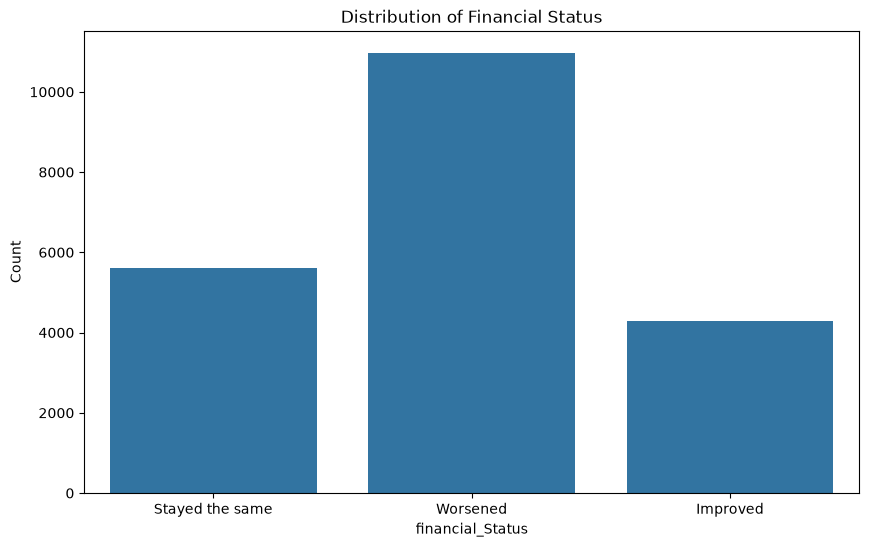

In [28]:
plt.figure(figsize = (10,6))
sns.countplot(financial_df, x='financial_status')

plt.title('Distribution of Financial Status')
plt.ylabel('Count')
plt.xlabel('financial_Status')
plt.show()

## percentage of formal savings in rural vs urbam

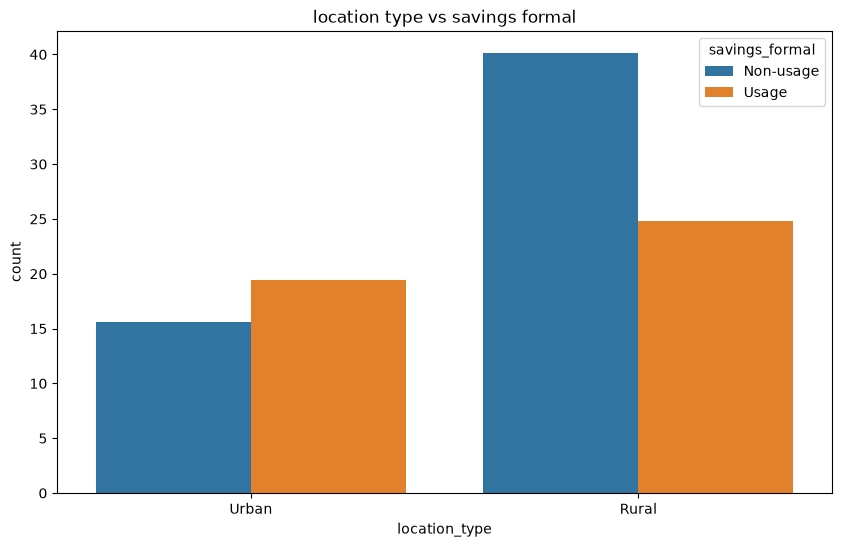

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(financial_df, x='location_type', hue='savings_formal', stat = 'percent')

plt.title('location type vs savings formal')
plt.ylabel('count')
plt.xlabel('location_type')
plt.show()

# Can we find the education levels for people with disabilities

In [30]:
disabled = financial_df[financial_df['has_disability']=='With Disability']

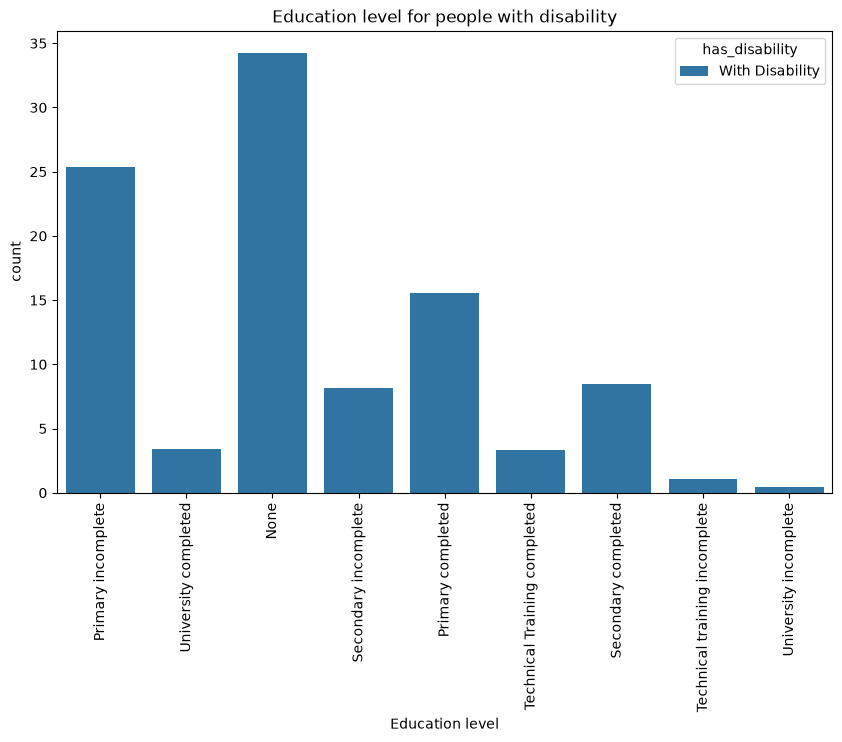

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(disabled, x='education_level', hue='has_disability', stat = 'percent')

plt.title('Education level for people with disability')
plt.ylabel('count')
plt.xlabel('Education level')
plt.xticks(rotation=90)
plt.show()

# can we find the distribution of household_size  based of the location_type

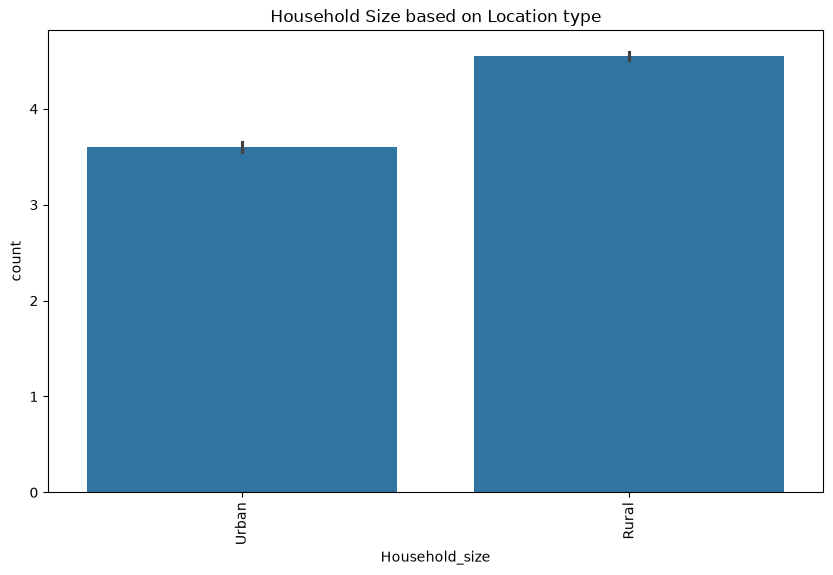

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(financial_df, x='location_type', y='household_size')

plt.title('Household Size based on Location type')
plt.ylabel('count')
plt.xlabel('Household_size')
plt.xticks(rotation=90)
plt.show()

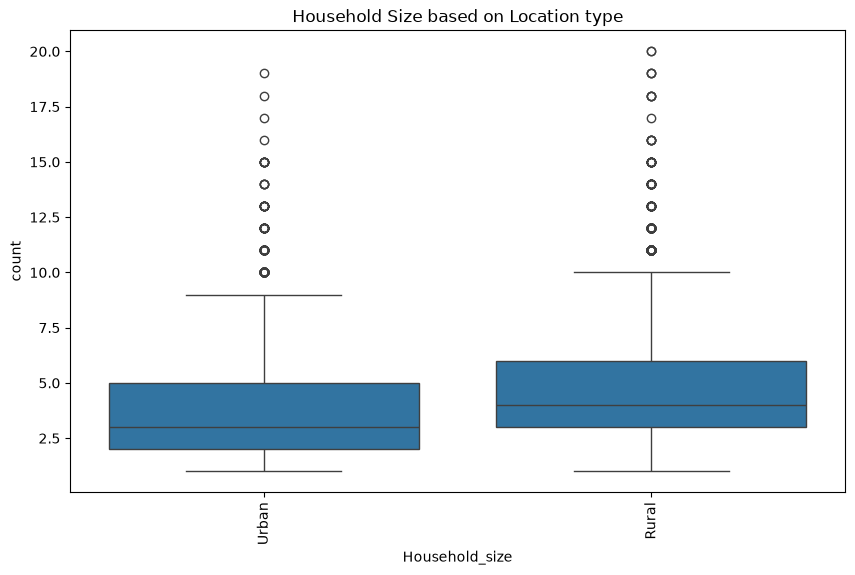

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(financial_df, x='location_type', y='household_size')

plt.title('Household Size based on Location type')
plt.ylabel('count')
plt.xlabel('Household_size')
plt.xticks(rotation=90)
plt.show()

# HYPOTHESIS TESTING

In [34]:
! pip install scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


_Testing the r/ship between categorical coulmns and target(target is categorical)_

In [35]:
# use chi square of independence

cat_cols = financial_df.select_dtypes(include=['str','object']).columns.to_list()

cat_cols

['county',
 'location_type',
 'sex',
 'age',
 'education_level',
 'marital_status',
 'savings_formal',
 'savings_informal',
 'loan_formal',
 'loan_informal',
 'defaulted',
 'formal_service_use',
 'mobile_money_access',
 'barriers_mobile_money',
 'mobile_ownership_1',
 'experienced_shock',
 'nfhi_11',
 'nfhi_12',
 'nfhi_13',
 'accessto_13k_1month',
 'not_difficult',
 'financial_status',
 'fl_score',
 'barriers_bank',
 'has_disability']

In [36]:
# Drop target

cat_cols.remove('financial_status')
cat_cols

['county',
 'location_type',
 'sex',
 'age',
 'education_level',
 'marital_status',
 'savings_formal',
 'savings_informal',
 'loan_formal',
 'loan_informal',
 'defaulted',
 'formal_service_use',
 'mobile_money_access',
 'barriers_mobile_money',
 'mobile_ownership_1',
 'experienced_shock',
 'nfhi_11',
 'nfhi_12',
 'nfhi_13',
 'accessto_13k_1month',
 'not_difficult',
 'fl_score',
 'barriers_bank',
 'has_disability']

In [37]:
for col in cat_cols:
    H0 = f'There is no relationship between {col} and financial_status'
    H1 = f'There is a relationship between {col} and financial_status'

    alpha = 0.05 # level of significance

    contingency_table = pd.crosstab(financial_df[col], financial_df['financial_status'])
    chi2_status, p_value, dof, expected = chi2_contingency(contingency_table)

    if p_value < alpha:
        print(f"Reject the null hypothesis that:'{H0}'")
    else:
        print(f"Fail to reject the null hypothesis that:'{H0}'")    


Reject the null hypothesis that:'There is no relationship between county and financial_status'
Reject the null hypothesis that:'There is no relationship between location_type and financial_status'
Reject the null hypothesis that:'There is no relationship between sex and financial_status'
Reject the null hypothesis that:'There is no relationship between age and financial_status'
Reject the null hypothesis that:'There is no relationship between education_level and financial_status'
Reject the null hypothesis that:'There is no relationship between marital_status and financial_status'
Reject the null hypothesis that:'There is no relationship between savings_formal and financial_status'
Reject the null hypothesis that:'There is no relationship between savings_informal and financial_status'
Reject the null hypothesis that:'There is no relationship between loan_formal and financial_status'
Reject the null hypothesis that:'There is no relationship between loan_informal and financial_status'
Re

In [38]:
print(contingency_table)

financial_status    Improved  Stayed the same  Worsened
has_disability                                         
With Disability           94              266       574
Without Disability      4185             5341     10393


In [39]:
print(expected)

[[  191.65520549   251.13595166   491.20884285]
 [ 4087.34479451  5355.86404834 10475.79115715]]


$E = \frac{\text{Row Total} \times \text{Column Total}}{\text{Grand Total}}$

In [40]:
# calculate the row total(improved)

row_total = 94 + 266 + 574
column_total = 94+4185
grand_total = 94+4185+266+5341+574+10393

expected_vals = (row_total * column_total) / grand_total

print(expected_vals)

191.6552054860212


_Numerical vs target hypothesis test:(Target is categorical)_

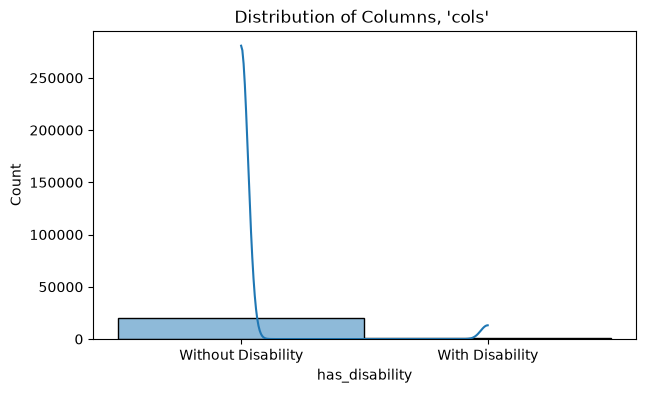

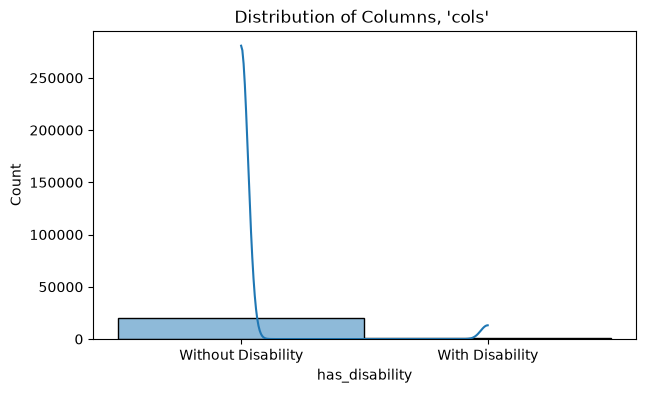

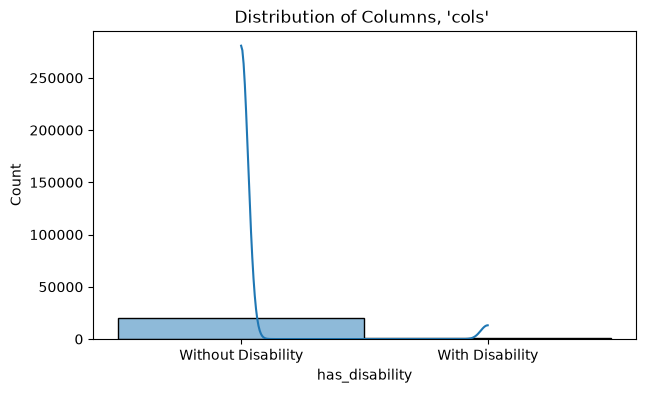

In [41]:
# check for normality of numerical column & homogenity of variance

numerical_cols = financial_df.select_dtypes(include=['float','int']).columns.to_list()

for cols in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(financial_df, x=col, kde=True)
    plt.title(f"Distribution of Columns, 'cols' ")
    plt.show()


In [42]:
# normality
for col in numerical_cols:
    print(financial_df.groupby("financial_status")[col].var())

financial_status
Improved           6.467929
Stayed the same    6.898233
Worsened           5.925923
Name: household_size, dtype: float64
financial_status
Improved           4.348968e+08
Stayed the same    1.687126e+08
Worsened           1.856094e+08
Name: monthly_income, dtype: float64
financial_status
Improved           12.176858
Stayed the same     9.802104
Worsened            9.739060
Name: prodsum1, dtype: float64


In [43]:
for col in numerical_cols:
    H0 = f"There is no difference in the distribution of : {col} across financial status"
    H1 = f"There is a difference in atleast one distribution of : {col} across financial status"

    alpha = 0.05

    num_groups = [group[col].values for name, group in financial_df.groupby('financial_status')]
    hstat, p_value = kruskal(*num_groups)

    if p_value <= alpha:
        print(f"Reject the null hypothesis: '{H0}'")
    else:
        print(f"Fail to rejetc the null hypothesis: '{H0}'")

Reject the null hypothesis: 'There is no difference in the distribution of : household_size across financial status'
Reject the null hypothesis: 'There is no difference in the distribution of : monthly_income across financial status'
Reject the null hypothesis: 'There is no difference in the distribution of : prodsum1 across financial status'


_correlation analysis_

                household_size  monthly_income  prodsum1
household_size        1.000000       -0.116445 -0.157133
monthly_income       -0.116445        1.000000  0.433239
prodsum1             -0.157133        0.433239  1.000000


<Axes: >

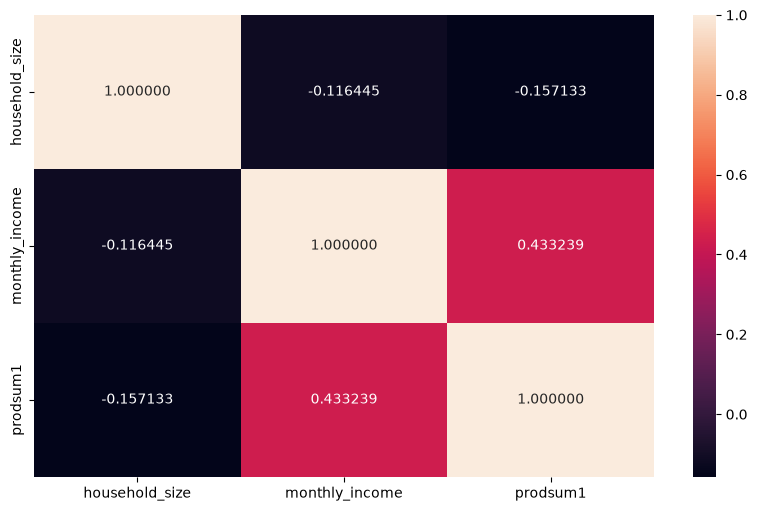

In [44]:
# Numerical Vs Numerical testing: Correlation analysis

correlation =  financial_df[numerical_cols].corr(method="spearman")

print(correlation)

# plot the correlation heatmap

plt.figure(figsize = (10,6))
sns.heatmap(correlation, annot= True, fmt="2f")

## Splitting the data into(Features and Target)

In [45]:
X = financial_df.drop(columns=['financial_status'])
y = financial_df['financial_status']

In [46]:
X.columns

Index(['county', 'location_type', 'sex', 'age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'savings_formal',
       'savings_informal', 'loan_formal', 'loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score',
       'prodsum1', 'barriers_bank', 'has_disability'],
      dtype='str')

### Splitting into test and train set

In [47]:
X_train , X_test ,y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [48]:
X_train.head()

,county,location_type,sex,age,household_size,education_level,marital_status,monthly_income,savings_formal,savings_informal,loan_formal,loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,fl_score,prodsum1,barriers_bank,has_disability
6573,Kiambu,Urban,Male,26-35,6,Secondary completed,Married,20000,Usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,None,Yes,No,Yes,Yes,Yes,Yes,Yes,All correct,6,Affordability,Without Disability
6207,Samburu,Rural,Male,Above 55,8,None,Married,8000,Usage,Non-usage,Non-usage,Usage,No,Usage,Yes,None,Yes,No,Yes,Yes,No,Yes,Yes,All correct,3,Affordability,Without Disability
15065,Turkana,Rural,Male,18-25,5,Secondary completed,Single,3000,Non-usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,None,Yes,Yes,No,No,Yes,No,No,All correct,2,Access,Without Disability
4541,Migori,Urban,Female,26-35,4,Secondary completed,Single,2000,Non-usage,Usage,Usage,Usage,No,Usage,Yes,None,Yes,Yes,No,No,No,No,No,All correct,7,Affordability,Without Disability
6632,Marsabit,Rural,Male,18-25,8,Secondary completed,Married,6000,Usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,None,Yes,No,Yes,Yes,Yes,Yes,No,Two correct,2,Affordability,Without Disability


In [49]:
X_test.head()

,county,location_type,sex,age,household_size,education_level,marital_status,monthly_income,savings_formal,savings_informal,loan_formal,loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,fl_score,prodsum1,barriers_bank,has_disability
10984,Trans Nzoia,Urban,Male,16-17,6,Secondary incomplete,Single,4000,Non-usage,Non-usage,Non-usage,Non-usage,No,Non-usage,No,Phone ownership,No,No,Yes,Yes,Yes,Yes,No,One correct,0,Eligibility,Without Disability
10848,Tharaka-Nithi,Urban,Male,26-35,4,Primary completed,Married,5000,Usage,Usage,Usage,Usage,No,Usage,Yes,None,Yes,Yes,Yes,Yes,Yes,Yes,Yes,All correct,10,Relevance/Suitability,Without Disability
10900,Garissa,Rural,Female,Above 55,3,None,Windowed,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,No,Awareness,No,No,No,No,Yes,No,No,Two correct,1,Affordability,Without Disability
13324,Mandera,Rural,Male,36-45,6,Primary completed,Married,10000,Usage,Non-usage,Usage,Usage,No,Usage,Yes,None,Yes,Yes,Yes,Yes,Yes,Yes,No,Two correct,10,Affordability,Without Disability
5090,Nandi,Rural,Female,26-35,6,Secondary completed,Windowed,3000,Non-usage,Non-usage,Non-usage,Non-usage,No,Non-usage,No,Phone ownership,No,No,Yes,Yes,Yes,No,No,Two correct,0,Awareness,Without Disability


## Pre-processing(Encoding and scaling)

__Encoding the target__

In [50]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

__Encoding the feature categorical columns__

In [51]:
financial_df['age'].unique()

<StringArray>
['26-35', 'Above 55', '18-25', '36-45', '46-55', '16-17']
Length: 6, dtype: str

In [52]:
age_order = ['16-17', '18-25', '26-35', '36-45', '46-55', 'Above 55']

In [53]:
encoder = OrdinalEncoder(categories=[age_order])
X_train["age"]= encoder.fit_transform(X_train[["age"]])
X_test["age"]= encoder.transform(X_test[["age"]])
        

In [54]:
X_train.head()

,county,location_type,sex,age,household_size,education_level,marital_status,monthly_income,savings_formal,savings_informal,loan_formal,loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,fl_score,prodsum1,barriers_bank,has_disability
6573,Kiambu,Urban,Male,2.0,6,Secondary completed,Married,20000,Usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,None,Yes,No,Yes,Yes,Yes,Yes,Yes,All correct,6,Affordability,Without Disability
6207,Samburu,Rural,Male,5.0,8,None,Married,8000,Usage,Non-usage,Non-usage,Usage,No,Usage,Yes,None,Yes,No,Yes,Yes,No,Yes,Yes,All correct,3,Affordability,Without Disability
15065,Turkana,Rural,Male,1.0,5,Secondary completed,Single,3000,Non-usage,Non-usage,Usage,Non-usage,Yes,Usage,Yes,None,Yes,Yes,No,No,Yes,No,No,All correct,2,Access,Without Disability
4541,Migori,Urban,Female,2.0,4,Secondary completed,Single,2000,Non-usage,Usage,Usage,Usage,No,Usage,Yes,None,Yes,Yes,No,No,No,No,No,All correct,7,Affordability,Without Disability
6632,Marsabit,Rural,Male,1.0,8,Secondary completed,Married,6000,Usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,None,Yes,No,Yes,Yes,Yes,Yes,No,Two correct,2,Affordability,Without Disability


In [55]:
financial_df['education_level'].unique()

array(['Technical Training completed', 'None', 'Primary completed',
       'Secondary incomplete', 'Technical training incomplete',
       'Secondary completed', 'Primary incomplete',
       'University completed', 'University incomplete'], dtype=object)

In [56]:
cat_cols_2=cat_cols.remove('age')
cat_cols_2

In [57]:
X_train = pd.get_dummies(X_train, columns=cat_cols_2,dtype=int,drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols_2,dtype=int,drop_first=True)

In [58]:
X_test.head()

,age,household_size,monthly_income,prodsum1,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,county_Homabay,county_Isiolo,county_Kajiado,county_Kakamega,county_Kericho,county_Kiambu,county_Kilifi,county_Kirinyaga,county_Kisii,county_Kisumu,county_Kitui,county_Kwale,county_Laikipia,county_Lamu,county_Machakos,county_Makueni,county_Mandera,county_Marsabit,county_Meru,county_Migori,county_Mombasa,county_Murang'a,county_Nairobi City,county_Nakuru,county_Nandi,county_Narok,county_Nyamira,county_Nyandarua,county_Nyeri,county_Samburu,county_Siaya,county_Taita-Taveta,county_Tana River,county_Tharaka-Nithi,county_Trans Nzoia,county_Turkana,county_Uasin Gishu,county_Vihiga,county_Wajir,county_West Pokot,location_type_Urban,sex_Male,education_level_Primary completed,education_level_Primary incomplete,education_level_Secondary completed,education_level_Secondary incomplete,education_level_Technical Training completed,education_level_Technical training incomplete,education_level_University completed,education_level_University incomplete,marital_status_Married,marital_status_Single,marital_status_Windowed,savings_formal_Usage,savings_informal_Usage,loan_formal_Usage,loan_informal_Usage,defaulted_Yes,formal_service_use_Usage,mobile_money_access_Yes,barriers_mobile_money_Awareness,barriers_mobile_money_Eligibility,barriers_mobile_money_Line blocked,barriers_mobile_money_None,barriers_mobile_money_Other,barriers_mobile_money_Phone ownership,barriers_mobile_money_Relevance/Suitability,barriers_mobile_money_Service quality,barriers_mobile_money_Trust,mobile_ownership_1_Yes,experienced_shock_Yes,nfhi_11_Yes,nfhi_12_Yes,nfhi_13_Yes,accessto_13k_1month_Yes,not_difficult_Yes,fl_score_None correct,fl_score_One correct,fl_score_Two correct,barriers_bank_Affordability,barriers_bank_Awareness,barriers_bank_Charges/Product pricing,barriers_bank_Eligibility,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability
10984,0.0,6,4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0,1
10848,2.0,4,5000,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,1,1,1,1,0,1,1,0,0,0,1,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1
10900,5.0,3,10000,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1
13324,3.0,6,10000,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,1,1,0,1,1,0,0,0,1,0,0,0,0,0,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1
5090,2.0,6,3000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1


__Scaling Numerical Columns__

In [59]:
numerical_cols

['household_size', 'monthly_income', 'prodsum1']

In [60]:
scaler = RobustScaler()

In [61]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [62]:
X_train.head()

,age,household_size,monthly_income,prodsum1,county_Bomet,county_Bungoma,county_Busia,county_Elgeyo-Marakwet,county_Embu,county_Garissa,county_Homabay,county_Isiolo,county_Kajiado,county_Kakamega,county_Kericho,county_Kiambu,county_Kilifi,county_Kirinyaga,county_Kisii,county_Kisumu,county_Kitui,county_Kwale,county_Laikipia,county_Lamu,county_Machakos,county_Makueni,county_Mandera,county_Marsabit,county_Meru,county_Migori,county_Mombasa,county_Murang'a,county_Nairobi City,county_Nakuru,county_Nandi,county_Narok,county_Nyamira,county_Nyandarua,county_Nyeri,county_Samburu,county_Siaya,county_Taita-Taveta,county_Tana River,county_Tharaka-Nithi,county_Trans Nzoia,county_Turkana,county_Uasin Gishu,county_Vihiga,county_Wajir,county_West Pokot,location_type_Urban,sex_Male,education_level_Primary completed,education_level_Primary incomplete,education_level_Secondary completed,education_level_Secondary incomplete,education_level_Technical Training completed,education_level_Technical training incomplete,education_level_University completed,education_level_University incomplete,marital_status_Married,marital_status_Single,marital_status_Windowed,savings_formal_Usage,savings_informal_Usage,loan_formal_Usage,loan_informal_Usage,defaulted_Yes,formal_service_use_Usage,mobile_money_access_Yes,barriers_mobile_money_Awareness,barriers_mobile_money_Eligibility,barriers_mobile_money_Line blocked,barriers_mobile_money_None,barriers_mobile_money_Other,barriers_mobile_money_Phone ownership,barriers_mobile_money_Relevance/Suitability,barriers_mobile_money_Service quality,barriers_mobile_money_Trust,mobile_ownership_1_Yes,experienced_shock_Yes,nfhi_11_Yes,nfhi_12_Yes,nfhi_13_Yes,accessto_13k_1month_Yes,not_difficult_Yes,fl_score_None correct,fl_score_One correct,fl_score_Two correct,barriers_bank_Affordability,barriers_bank_Awareness,barriers_bank_Charges/Product pricing,barriers_bank_Eligibility,barriers_bank_Other,barriers_bank_Relevance/Suitability,barriers_bank_Service quality,barriers_bank_Trust,has_disability_Without Disability
6573,2.0,0.50,2.000000,0.6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1
6207,5.0,1.00,0.400000,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1
15065,1.0,0.25,-0.266667,-0.2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4541,2.0,0.00,-0.400000,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,1,0,1,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
6632,1.0,1.00,0.133333,-0.2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,1,1,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1


### Logistic Regression Model

In [63]:
# Instantiate the model

logistic_model = LogisticRegression(max_iter=1000)

In [64]:
# Fit the model to the training data

logistic_model.fit(X_train, y_train_encoded)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [65]:
# Make predictions on the test set

y_pred = logistic_model.predict(X_test)

In [66]:
# Evaluating the logistics regression model

print('classification_report \n', classification_report(y_test_encoded,y_pred, target_names= le.classes_))


classification_report 
                  precision    recall  f1-score   support

       Improved       0.48      0.31      0.38       856
Stayed the same       0.48      0.24      0.32      1121
       Worsened       0.61      0.86      0.71      2194

       accuracy                           0.58      4171
      macro avg       0.53      0.47      0.47      4171
   weighted avg       0.55      0.58      0.54      4171



## Ensemble models

_1. Decision Tree_

In [67]:
# Instantiate the model

decision_model = DecisionTreeClassifier(max_depth=10)

In [68]:
# Train the model on the training data

decision_model.fit(X_train, y_train_encoded)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [69]:
# Make predictions on the test set

decision_pred = decision_model.predict(X_test)

In [70]:
# Evaluate the model

print('Decision_tree_classification_report \n', classification_report(y_test_encoded,decision_pred, target_names= le.classes_))

Decision_tree_classification_report 
                  precision    recall  f1-score   support

       Improved       0.39      0.29      0.34       856
Stayed the same       0.43      0.21      0.28      1121
       Worsened       0.60      0.82      0.69      2194

       accuracy                           0.54      4171
      macro avg       0.47      0.44      0.43      4171
   weighted avg       0.51      0.54      0.51      4171



In [71]:
print(len(X_test))
print(856+1121+2194)

4171
4171


## KNN Neighbours

In [74]:
# Instantiate the model

knn_model = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

# Fit the model to the training data

knn_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

knn_pred = knn_model.predict(X_test)

# Evaluate the model

print("KNN_classification_report \n", classification_report(y_test_encoded,knn_pred, target_names= le.classes_))

KNN_classification_report 
                  precision    recall  f1-score   support

       Improved       0.36      0.29      0.32       856
Stayed the same       0.36      0.31      0.33      1121
       Worsened       0.61      0.71      0.66      2194

       accuracy                           0.51      4171
      macro avg       0.44      0.43      0.44      4171
   weighted avg       0.49      0.51      0.50      4171



In [75]:
# Instantiate the model

knn_model = KNeighborsClassifier(n_neighbors=7, metric='manhattan')

# Fit the model to the training data

knn_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

knn_pred = knn_model.predict(X_test)

# Evaluate the model

print("KNN_classification_report \n", classification_report(y_test_encoded,knn_pred, target_names= le.classes_))

KNN_classification_report 
                  precision    recall  f1-score   support

       Improved       0.35      0.29      0.32       856
Stayed the same       0.37      0.31      0.34      1121
       Worsened       0.62      0.71      0.66      2194

       accuracy                           0.52      4171
      macro avg       0.45      0.44      0.44      4171
   weighted avg       0.50      0.52      0.50      4171



In [76]:
# Instantiate the model

knn_model = KNeighborsClassifier(n_neighbors=7, metric='minkowski')

# Fit the model to the training data

knn_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

knn_pred = knn_model.predict(X_test)

# Evaluate the model

print("KNN_classification_report \n", classification_report(y_test_encoded,knn_pred, target_names= le.classes_))

KNN_classification_report 
                  precision    recall  f1-score   support

       Improved       0.36      0.29      0.32       856
Stayed the same       0.36      0.31      0.33      1121
       Worsened       0.61      0.71      0.66      2194

       accuracy                           0.51      4171
      macro avg       0.44      0.43      0.44      4171
   weighted avg       0.49      0.51      0.50      4171



# Ensemble Models
 ## Bagging
 - It is a combinationd of multiple models using different samples of the dataset to train and make more accurate prediction.
 - In regression it uses the average
 - Classification it uses majority vote

_2. Random Forest_


In [80]:
# Instantiate the model
random_forest = RandomForestClassifier(n_estimators=1000, max_depth=4)

# Train the model on the training data

random_forest.fit(X_train, y_train_encoded)

# Make predictions on the test set

rf_pred = random_forest.predict(X_test)

# Evaluate the model
print("Random Forest Classification Report \n", classification_report(y_test_encoded, rf_pred, target_names=le.classes_))


Random Forest Classification Report 
                  precision    recall  f1-score   support

       Improved       0.00      0.00      0.00       856
Stayed the same       0.47      0.06      0.11      1121
       Worsened       0.54      0.98      0.69      2194

       accuracy                           0.53      4171
      macro avg       0.34      0.35      0.27      4171
   weighted avg       0.41      0.53      0.40      4171



d:\FINANCIAL WELLBEING PREDICTION\fin_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\FINANCIAL WELLBEING PREDICTION\fin_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\FINANCIAL WELLBEING PREDICTION\fin_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

_3. Boosting_

In [83]:
# Gradient Boosting Classifier
# Instantiating the model

gb_model = GradientBoostingClassifier(n_estimators=1000, max_depth=4)

# Train the model on the training data

gb_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

gb_pred = gb_model.predict(X_test)

# Evaluate the model

print("Gradient Boosting Classification Report \n", classification_report(y_test_encoded, gb_pred, target_names=le.classes_))

Gradient Boosting Classification Report 
                  precision    recall  f1-score   support

       Improved       0.45      0.34      0.38       856
Stayed the same       0.43      0.27      0.33      1121
       Worsened       0.63      0.80      0.70      2194

       accuracy                           0.56      4171
      macro avg       0.50      0.47      0.47      4171
   weighted avg       0.54      0.56      0.54      4171



## XGBoost Model

In [88]:
# Instantiate the model

xgb_model = XGBClassifier(n_estimators=200, max_depth=4)

# Train the model on the training data

xgb_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

xgb_pred = xgb_model.predict(X_test)

# Evaluate the model

print("XGBoost Classification Report \n", classification_report(y_test_encoded, xgb_pred, target_names=le.classes_))

XGBoost Classification Report 
                  precision    recall  f1-score   support

       Improved       0.46      0.33      0.38       856
Stayed the same       0.44      0.24      0.31      1121
       Worsened       0.62      0.83      0.71      2194

       accuracy                           0.57      4171
      macro avg       0.51      0.47      0.47      4171
   weighted avg       0.54      0.57      0.54      4171



## SUPPORT VECTOR MACHINES (SVM)

In [91]:
# Instantiate the model

svm_model = SVC(kernel='rbf', gamma='auto')

# Train the model on the training data

svm_model.fit(X_train, y_train_encoded)

# Make predictions on the test set

svm_pred = svm_model.predict(X_test)

# Evaluate the model

print("SVM Classification Report \n", classification_report(y_test_encoded, svm_pred, target_names=le.classes_))

SVM Classification Report 
                  precision    recall  f1-score   support

       Improved       0.54      0.14      0.22       856
Stayed the same       0.47      0.13      0.20      1121
       Worsened       0.56      0.94      0.70      2194

       accuracy                           0.56      4171
      macro avg       0.52      0.40      0.38      4171
   weighted avg       0.53      0.56      0.47      4171

